# Wildfire risk exploration
We will explore the Next-Day Wildfire Spread TFRecord samples and visualize risk-related drivers (vegetation, temperature, drought, precipitation, wind proxy, energy release, population) alongside previous-day and next-day fire masks. Focus is on risk indicators, not detection, to support preparedness.

In [27]:
# Core imports
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict

In [28]:
# Paths and feature config
DATA_DIR = Path('/home/yash/Public/Sem-8/DisasterManagement/2')
tfrecord_paths = sorted(DATA_DIR.glob('next_day_wildfire_spread_*.tfrecord'))
assert tfrecord_paths, 'No TFRecords found. Check DATA_DIR.'

# All features are 64x64 grids flattened to length 4096
FEATURES = {
    'NDVI': 'Normalized Difference Vegetation Index',
    'tmmx': 'Max temp (K)',
    'tmmn': 'Min temp (K)',
    'pr': 'Precipitation (kg/m^2/s)',
    'pdsi': 'Palmer Drought Severity Index',
    'vs': 'Wind speed (m/s)',
    'th': 'Wind direction (deg from N)',
    'sph': 'Specific humidity (kg/kg)',
    'erc': 'Energy release component',
    'population': 'Population density (people/km^2)',
    'elevation': 'Elevation (m)',
    'PrevFireMask': 'Previous-day fire mask (0/1)',
    'FireMask': 'Next-day fire mask (target 0/1)',
}

In [29]:
# TFRecord parsing helpers
IMG_SIZE = 64
feature_description = {name: tf.io.FixedLenFeature([IMG_SIZE * IMG_SIZE], tf.float32) for name in FEATURES}

def decode_example(record_bytes: tf.Tensor) -> Dict[str, tf.Tensor]:
    parsed = tf.io.parse_single_example(record_bytes, feature_description)
    for key in parsed:
        parsed[key] = tf.reshape(parsed[key], (IMG_SIZE, IMG_SIZE))
    return parsed


def load_dataset(paths, shuffle=False):
    ds = tf.data.TFRecordDataset([str(p) for p in paths])
    if shuffle:
        ds = ds.shuffle(buffer_size=100)
    ds = ds.map(decode_example, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

In [30]:
# Quick sanity check on one record
ds_peek = load_dataset([tfrecord_paths[0]])
example = next(iter(ds_peek))
summary = {}
for k, v in example.items():
    arr = v.numpy()
    summary[k] = {'min': float(arr.min()), 'max': float(arr.max()), 'mean': float(arr.mean())}
pd.DataFrame(summary).T

,min,max,mean
FireMask,-1.000000,0.000000,-0.089844
NDVI,-4315.000000,7902.000000,5017.673828
PrevFireMask,-1.000000,1.000000,-0.002686
elevation,74.000000,155.000000,108.591553
erc,13.509377,22.505724,15.892441
pdsi,2.142175,3.877115,3.376486
population,0.000000,2167.714844,18.248913
pr,2.402361,7.125251,5.898406
sph,0.007909,0.009082,0.008598
th,140.819305,168.410858,158.898254


## Visual slices: drivers vs fire masks
Plot a single sample to see spatial patterns for key risk indicators and the previous/next-day masks.

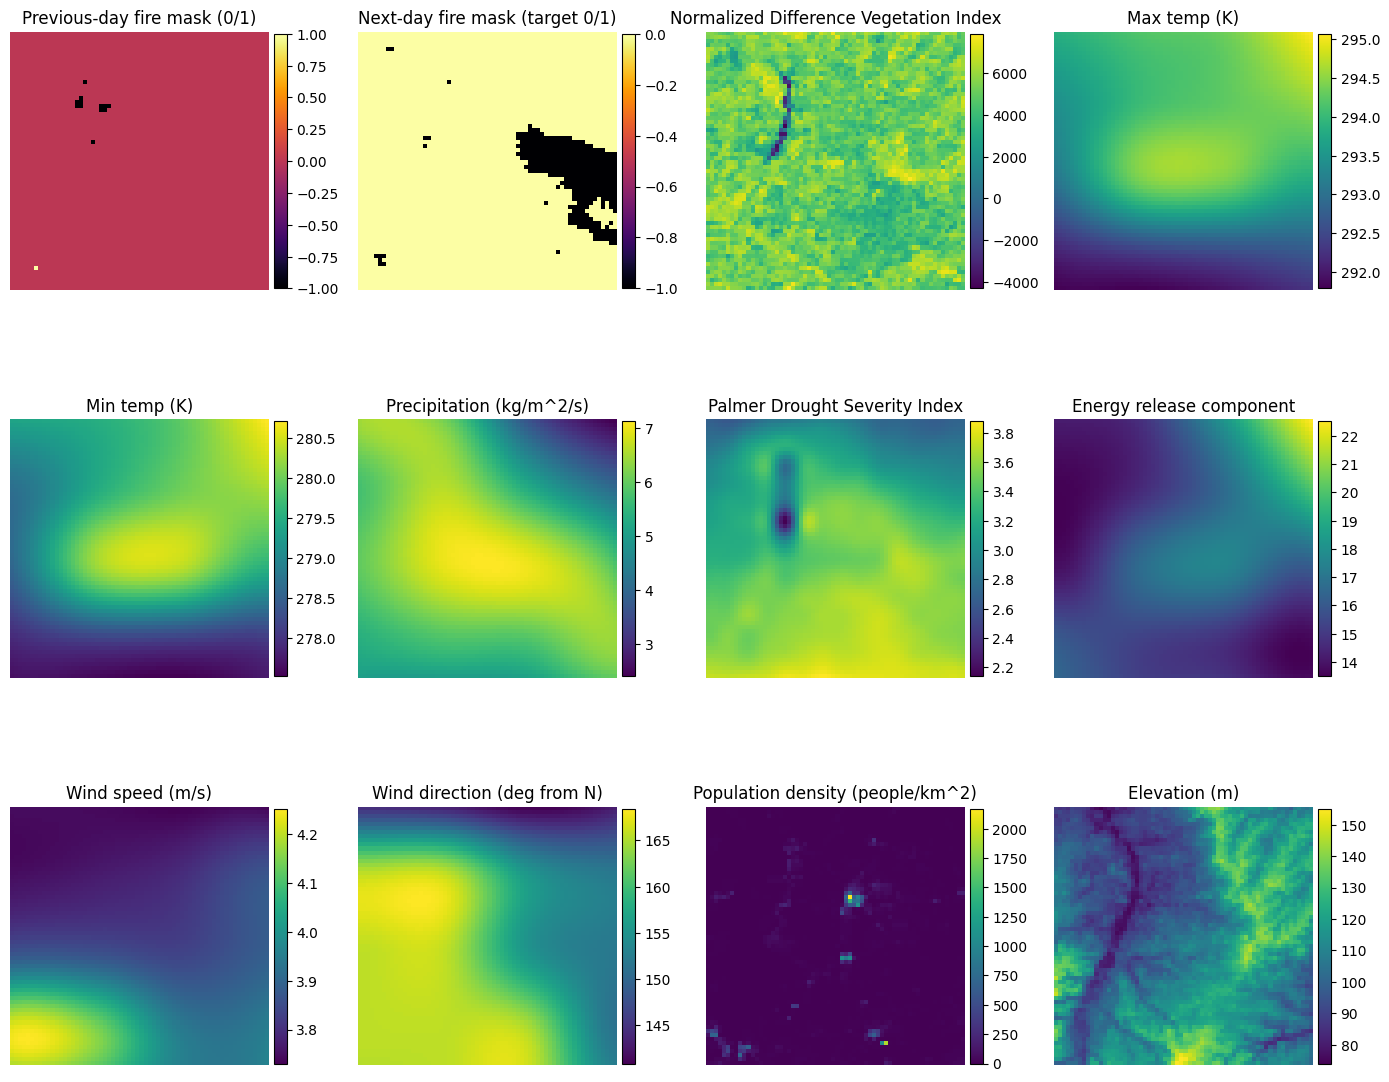

In [31]:
# Plot a single example
sample = {k: v.numpy() for k, v in example.items()}
plt.figure(figsize=(14, 12))
plot_features = ['PrevFireMask', 'FireMask', 'NDVI', 'tmmx', 'tmmn', 'pr', 'pdsi', 'erc', 'vs', 'th', 'population', 'elevation']
for i, key in enumerate(plot_features, 1):
    ax = plt.subplot(3, 4, i)
    im = ax.imshow(sample[key], cmap='inferno' if 'Mask' in key else 'viridis')
    ax.set_title(FEATURES[key])
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.tight_layout()
plt.show()

In [32]:
## Aggregate statistics across a small batch
subset = list(load_dataset(tfrecord_paths[:2]).take(64))  # small sample for speed
stacked = {k: np.stack([ex[k].numpy() for ex in subset]) for k in FEATURES}
stats_rows = []
for k, arr in stacked.items():
    stats_rows.append({
        'feature': k,
        'mean': float(arr.mean()),
        'std': float(arr.std()),
        'p10': float(np.percentile(arr, 10)),
        'p50': float(np.percentile(arr, 50)),
        'p90': float(np.percentile(arr, 90))
    })
stats_df = pd.DataFrame(stats_rows).set_index('feature').loc[list(FEATURES.keys())]
stats_df

,mean,std,p10,p50,p90
feature,,,,,
NDVI,4602.429199,2323.736328,1989.000000,4271.000000,7891.000000
tmmx,298.453827,18.641588,289.755511,299.564285,308.751343
tmmn,281.544556,17.236954,273.758878,282.917953,289.571777
pr,0.806559,3.685474,0.000000,0.000000,0.414508
pdsi,-0.048843,2.308226,-3.172481,0.000000,2.912803
vs,4.227257,1.958933,2.383512,3.777810,6.695173
th,186.004318,64.190903,99.386426,187.826347,268.676678
sph,0.005693,0.002499,0.003169,0.005288,0.008451
erc,51.787758,25.705433,26.699819,41.057398,89.030365


In [33]:
## Pixel-level relationships with fire occurrence
# Keep a modest subset to avoid memory blow-up
analysis_subset = list(load_dataset(tfrecord_paths[:1]).take(16))
records = []
for ex in analysis_subset:
    fm = ex['FireMask'].numpy().reshape(-1)
    prev = ex['PrevFireMask'].numpy().reshape(-1)
    for key in ['NDVI', 'tmmx', 'tmmn', 'pr', 'pdsi', 'erc', 'vs', 'population']:
        records.append(pd.DataFrame({
            'feature': key,
            'value': ex[key].numpy().reshape(-1),
            'fire': fm,
            'prev_fire': prev
        }))
pixels = pd.concat(records, ignore_index=True)

# Correlation (Pearson) of feature value vs fire indicator
corrs = pixels.groupby('feature').apply(lambda df: df['value'].corr(df['fire'])).rename('fire_corr').reset_index()
corrs

,feature,fire_corr
0,NDVI,0.029937
1,erc,0.166033
2,pdsi,-0.089121
3,population,0.030968
4,pr,-0.335208
5,tmmn,0.040559
6,tmmx,0.110131
7,vs,-0.412896


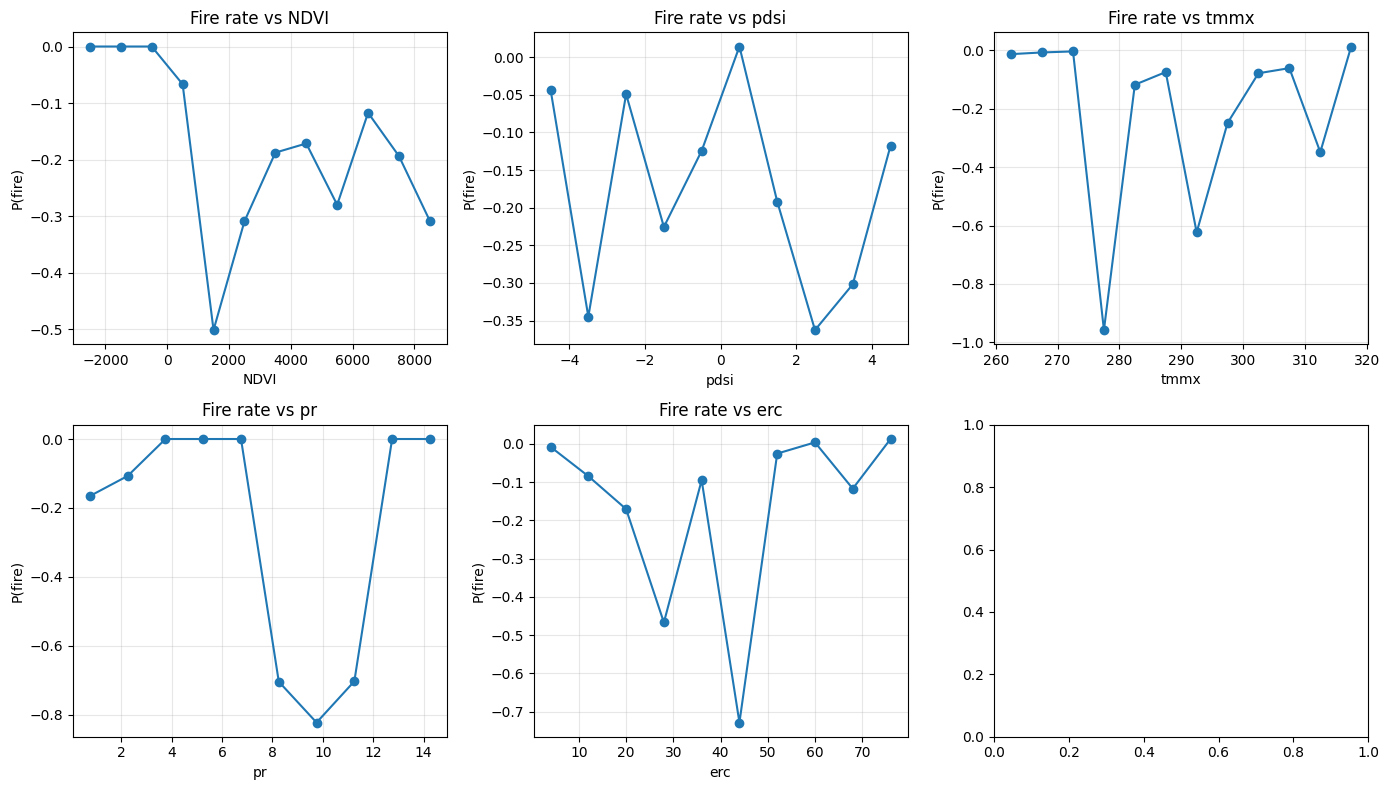

In [34]:
# Fire rate vs binned drivers
bin_defs = {
    'NDVI': (-3000, 9000, 12),
    'pdsi': (-5, 5, 10),
    'tmmx': (260, 320, 12),
    'pr': (0, 15, 10),
    'erc': (0, 80, 10)
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
for ax, (feat, (lo, hi, bins)) in zip(axes, bin_defs.items()):
    df = pixels[pixels['feature'] == feat].copy()
    df['bin'] = pd.cut(df['value'], bins=bins, labels=False, include_lowest=True, right=False)
    agg = df.groupby('bin').agg(fire_rate=('fire', 'mean'), count=('fire', 'size'))
    agg['center'] = np.linspace(lo, hi, bins, endpoint=False) + (hi - lo) / bins / 2
    ax.plot(agg['center'], agg['fire_rate'], marker='o')
    ax.set_title(f'Fire rate vs {feat}')
    ax.set_xlabel(feat)
    ax.set_ylabel('P(fire)')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

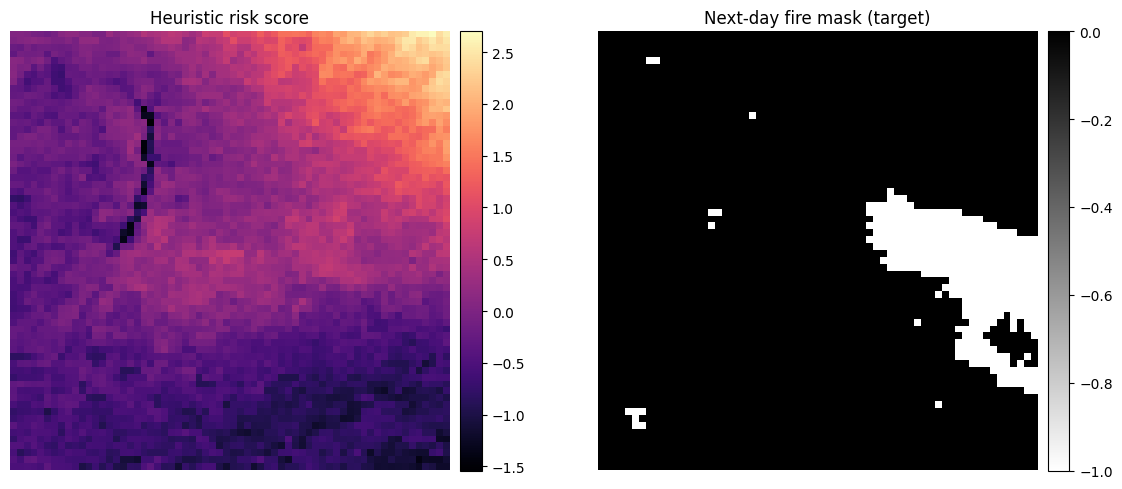

In [35]:
## Simple heuristic risk surface (for intuition, not a model)
weights = {
    'tmmx': 0.35,  # hotter -> riskier
    'erc': 0.25,   # energy release -> riskier
    'NDVI': 0.2,   # more fuel -> riskier
    'pdsi': -0.1,  # wetter (higher PDSI) -> safer
    'pr': -0.2     # more rain -> safer
}

# Z-score normalize per feature for this sample
risk_terms = []
for feat, w in weights.items():
    arr = sample[feat]
    z = (arr - arr.mean()) / (arr.std() + 1e-6)
    risk_terms.append(w * z)
risk_map = np.clip(np.sum(risk_terms, axis=0), -3, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(risk_map, cmap='magma')
axes[0].set_title('Heuristic risk score')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)

im1 = axes[1].imshow(sample['FireMask'], cmap='binary')
axes[1].set_title('Next-day fire mask (target)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)
plt.tight_layout()
plt.show()

## Next steps
- Train a lightweight risk model (e.g., logistic regression or shallow CNN) using the decoded grids, targeting `FireMask` and using the environmental drivers as channels.
- Add temporal smoothing: include `PrevFireMask` and lagged meteorology to capture persistence.
- Evaluate on held-out TFRecords and visualize precision-recall plus spatial error maps (false positives vs false negatives).

## CA 2020 mapped dataset (hazard-focused) overview
Using the canonical CA 2020 mapped dataset exported from NDWS (see channels/manifest/index files). We will inspect split composition, temporal coverage, spatial footprint, and channel definitions to align visuals with the hazard-first pipeline.

In [36]:
# Load CA2020 mapped dataset metadata
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CA_DATA_DIR = Path('/home/yash/Public/Sem-8/DisasterManagement/wildfire_ndws_ca2020_full_v2')
channels_meta = json.loads(CA_DATA_DIR.joinpath('channels_metadata.json').read_text())
manifest_df = pd.read_csv(CA_DATA_DIR.joinpath('sample_manifest.csv'))
index_df = pd.read_csv(CA_DATA_DIR.joinpath('sample_index.csv'))

channels_meta['channel_names'], len(manifest_df), manifest_df.split.value_counts().to_dict()

(['elevation',
  'th',
  'vs',
  'tmmn',
  'tmmx',
  'sph',
  'pr',
  'pdsi',
  'NDVI',
  'population',
  'erc',
  'PrevFireMask',
  'meta_lon_z',
  'meta_lat_z',
  'meta_day_of_year_z'],
 61064,
 {'train': 50142, 'eval': 5525, 'test': 5397})

In [37]:
# Split and temporal coverage summary
manifest_df['sample_date'] = pd.to_datetime(manifest_df['sample_date'])
split_counts = manifest_df['split'].value_counts().rename_axis('split').reset_index(name='count')
date_range = (manifest_df['sample_date'].min(), manifest_df['sample_date'].max())
daily_counts = manifest_df.groupby(['split', manifest_df['sample_date'].dt.to_period('M')]).size().reset_index(name='count')
daily_counts['month'] = daily_counts['sample_date'].dt.to_timestamp()
summary_table = pd.DataFrame({
    'rows_total': [len(manifest_df)],
    'splits': [split_counts.set_index('split')['count'].to_dict()],
    'date_min': [str(date_range[0].date())],
    'date_max': [str(date_range[1].date())],
    'channels': [channels_meta['channel_names']]
})
summary_table

,rows_total,splits,date_min,date_max,channels
0,61064,"{'train': 50142, 'eval': 5525, 'test': 5397}",2020-01-01,2020-12-31,"[elevation, th, vs, tmmn, tmmx, sph, pr, pdsi,..."


In [38]:
# Channel table (base vs metadata)
base = channels_meta['base_channels']
meta = channels_meta['meta_channels']
chan_rows = []
for name in channels_meta['channel_names']:
    chan_rows.append({
        'channel': name,
        'type': 'base' if name in base else 'meta',
        'data_dtype': channels_meta.get('data_dtype', 'float32') if name != 'FireMask' else channels_meta.get('label_dtype', 'uint8')
    })
chan_df = pd.DataFrame(chan_rows)
chan_df

,channel,type,data_dtype
0,elevation,base,float16
1,th,base,float16
2,vs,base,float16
3,tmmn,base,float16
4,tmmx,base,float16
5,sph,base,float16
6,pr,base,float16
7,pdsi,base,float16
8,NDVI,base,float16
9,population,base,float16


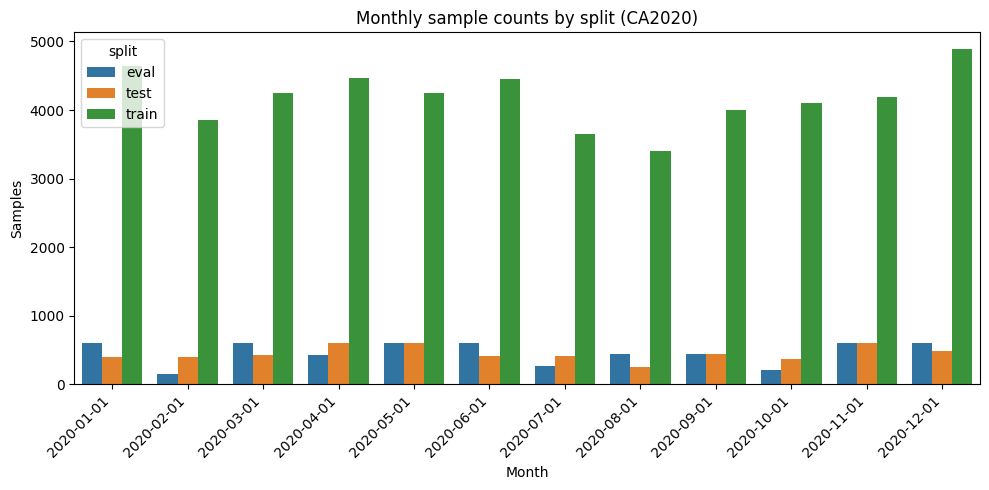

In [39]:
# Monthly sample volume by split
plt.figure(figsize=(10, 5))
sns.barplot(data=daily_counts, x='month', y='count', hue='split')
plt.xticks(rotation=45, ha='right')
plt.title('Monthly sample counts by split (CA2020)')
plt.xlabel('Month')
plt.ylabel('Samples')
plt.tight_layout()
plt.show()

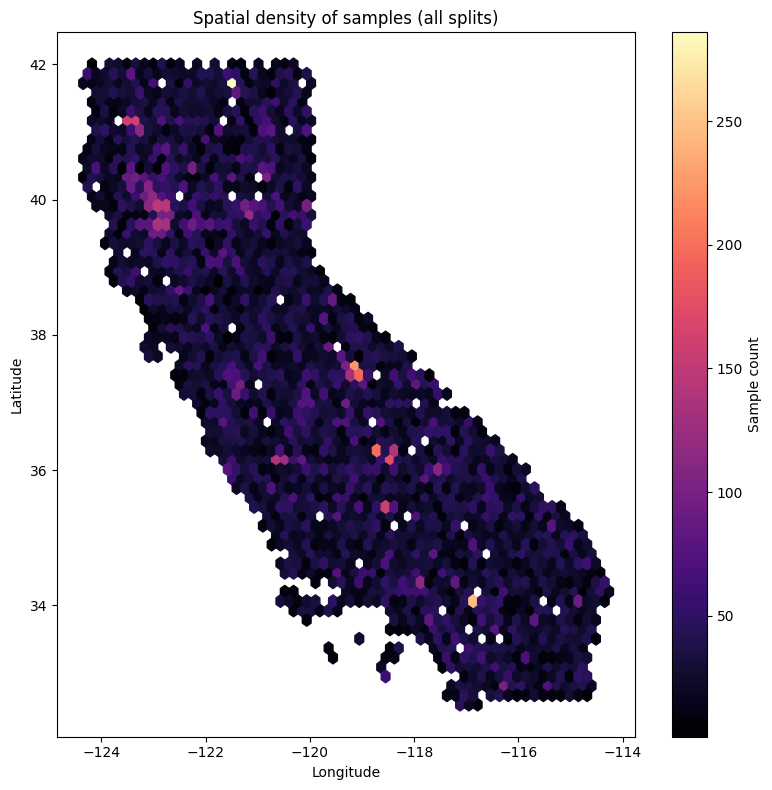

In [40]:
# Spatial footprint (hexbin density)
plt.figure(figsize=(8, 8))
plt.hexbin(index_df['sample_lon'], index_df['sample_lat'], gridsize=60, cmap='magma', mincnt=1)
plt.colorbar(label='Sample count')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Spatial density of samples (all splits)')
plt.tight_layout()
plt.show()

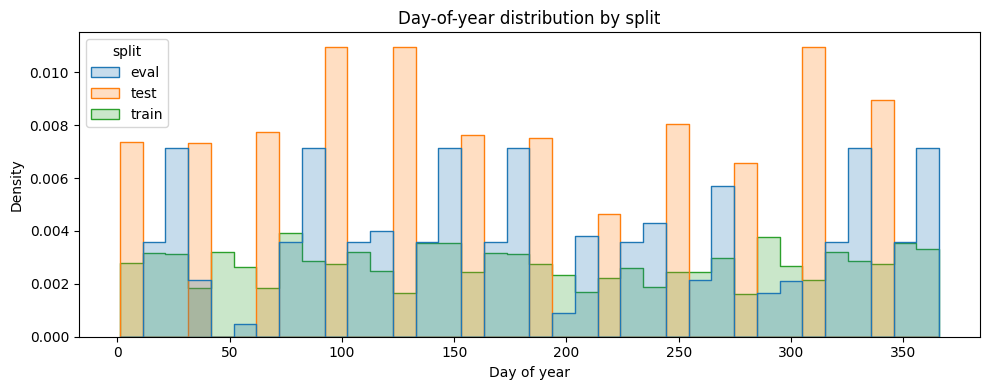

In [41]:
# Day-of-year coverage by split
manifest_df['doy'] = manifest_df['sample_date'].dt.dayofyear
plt.figure(figsize=(10, 4))
sns.histplot(data=manifest_df, x='doy', hue='split', bins=36, element='step', stat='density', common_norm=False)
plt.title('Day-of-year distribution by split')
plt.xlabel('Day of year')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## Pipeline snapshot (hazard → risk)
```mermaid
graph LR
  A[NDWS CA 2020 TFRecords (64x64)] --> B[Channel build (12 env + 3 meta)]
  B --> C[Hazard dataset pickles (float16/uint8)]
  C --> D[U-Net hazard training]
  D --> E[Hazard inference maps]
  E --> F[Risk fusion (hazard × exposure × vulnerability)]
  F --> G[Risk tiers, EAL, frontend layers]
```


## Additional dataset visuals (splits, space, time)
Quick views over the CA 2020 mapped metadata to spot coverage and split balance.

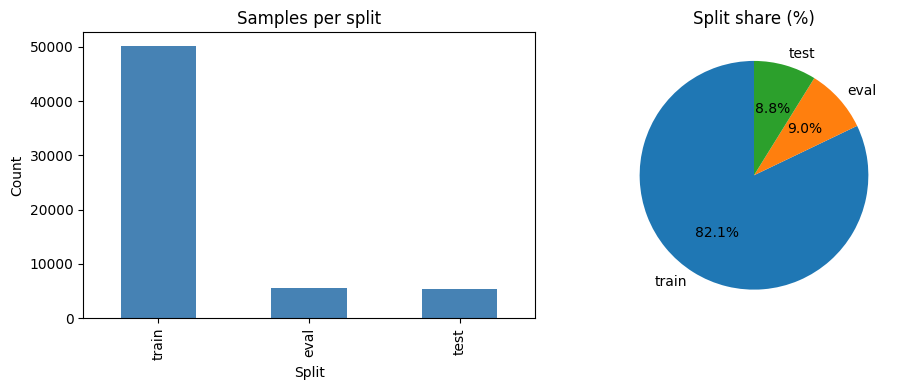

In [42]:
# Split composition bar/pie
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
split_counts.plot(kind='bar', x='split', y='count', ax=axes[0], legend=False, color='steelblue')
axes[0].set_title('Samples per split')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Split')
axes[1].pie(split_counts['count'], labels=split_counts['split'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Split share (%)')
plt.tight_layout()
plt.show()

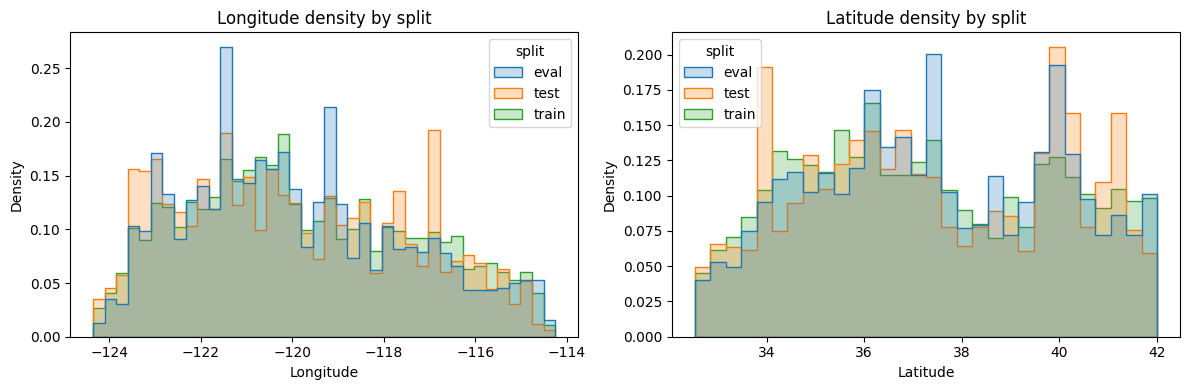

In [43]:
# Longitude / latitude distributions by split
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=manifest_df, x='sample_lon', hue='split', bins=40, element='step', stat='density', common_norm=False, ax=axes[0])
axes[0].set_title('Longitude density by split')
axes[0].set_xlabel('Longitude')
sns.histplot(data=manifest_df, x='sample_lat', hue='split', bins=30, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Latitude density by split')
axes[1].set_xlabel('Latitude')
plt.tight_layout()
plt.show()

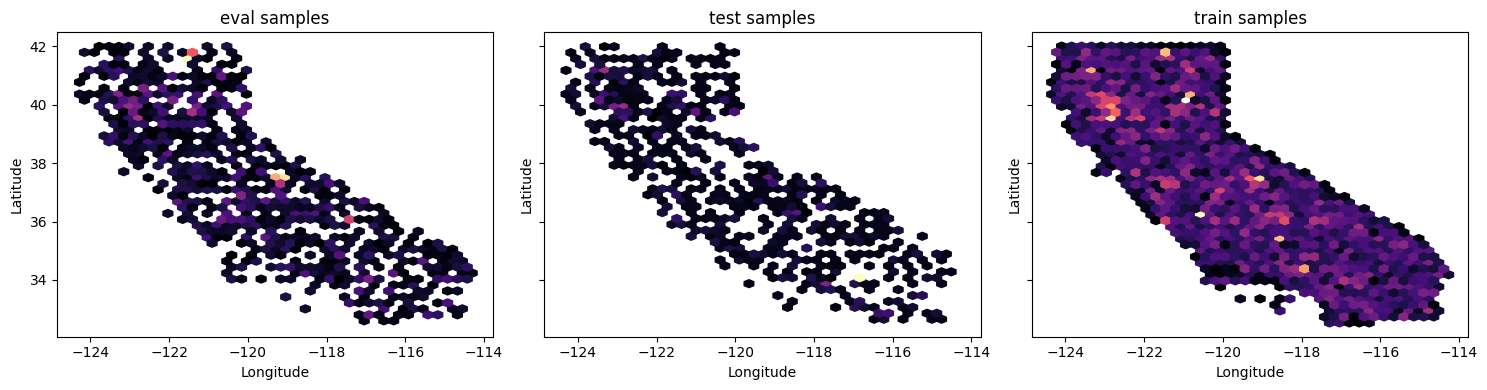

In [44]:
# Spatial density per split (hexbin small multiples)
splits = manifest_df['split'].unique()
fig, axes = plt.subplots(1, len(splits), figsize=(5 * len(splits), 4), sharex=True, sharey=True)
if len(splits) == 1:
    axes = [axes]
for ax, sp in zip(axes, splits):
    sub = manifest_df[manifest_df['split'] == sp]
    hb = ax.hexbin(sub['sample_lon'], sub['sample_lat'], gridsize=40, cmap='magma', mincnt=1)
    ax.set_title(f'{sp} samples')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

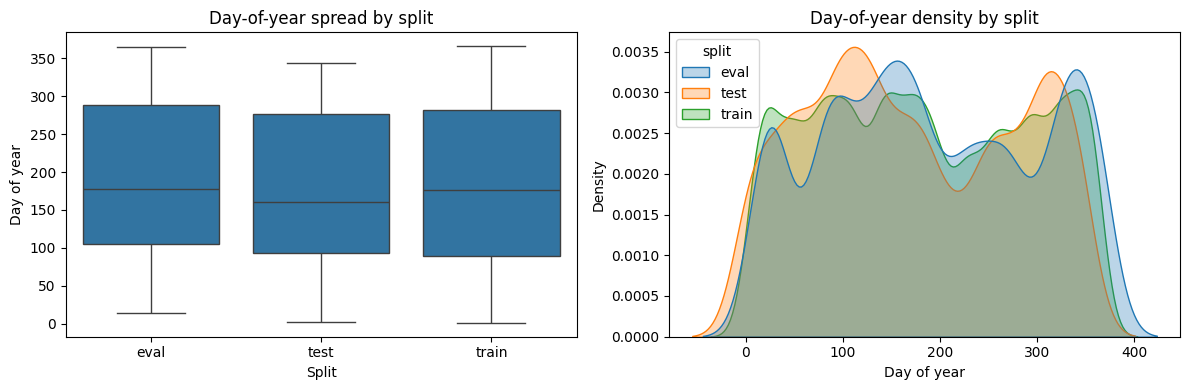

In [45]:
# Day-of-year coverage by split (box + KDE)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=manifest_df, x='split', y='doy', ax=axes[0])
axes[0].set_title('Day-of-year spread by split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Day of year')
sns.kdeplot(data=manifest_df, x='doy', hue='split', common_norm=False, fill=True, alpha=0.3, ax=axes[1])
axes[1].set_title('Day-of-year density by split')
axes[1].set_xlabel('Day of year')
plt.tight_layout()
plt.show()

## Note on fire-mask prevalence
Label files are not present in this workspace snapshot, so fire-pixel prevalence by split cannot be plotted directly here. If you add `train/validation/test.labels` (or a small sample), we can chart fire fractions per split and per month to highlight class imbalance and seasonality.

## Training log metrics (model_results.txt)
Parse the training log to summarize validation metrics across epochs for reporting.

In [46]:
# Parse validation metrics from log
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

log_path = Path('/home/yash/Public/Sem-8/DisasterManagement/DisasterProject/model_results.txt')
text = log_path.read_text()

pattern = re.compile(r"Validation - Loss: ([0-9.]+), IoU: ([0-9.]+), Accuracy: ([0-9.]+)\nF1 Score: ([0-9.]+), AUC: ([0-9.]+), Dice: ([0-9.]+)\nPrecision: ([0-9.]+), Recall: ([0-9.]+)\nEpoch \[(\d+)/\d+\] LR: ([0-9.]+)")
rows = []
for m in pattern.finditer(text):
    loss, iou, acc, f1, auc, dice, prec, rec, epoch, lr = m.groups()
    rows.append({
        'epoch': int(epoch),
        'loss': float(loss),
        'IoU': float(iou),
        'Accuracy': float(acc),
        'F1': float(f1),
        'AUC': float(auc),
        'Dice': float(dice),
        'Precision': float(prec),
        'Recall': float(rec),
        'LR': float(lr)
    })
metrics_df = pd.DataFrame(rows).sort_values('epoch').reset_index(drop=True)
metrics_df

,epoch,loss,IoU,Accuracy,F1,AUC,Dice,Precision,Recall,LR
0,1,2.6661,0.5086,0.9740,0.5329,0.9263,0.5329,0.5482,0.6118,0.00070
1,2,2.1751,0.5860,0.9853,0.6507,0.9317,0.6507,0.6106,0.7619,0.00070
2,3,3.0750,0.5374,0.9933,0.5690,0.9155,0.5690,0.6709,0.5484,0.00070
3,4,2.4413,0.5304,0.9572,0.5808,0.9036,0.5808,0.5562,0.7695,0.00070
4,5,3.4662,0.5415,0.9932,0.5778,0.9202,0.5778,0.6849,0.5533,0.00042
5,6,3.3281,0.5473,0.9931,0.5862,0.9256,0.5862,0.6743,0.5618,0.00042


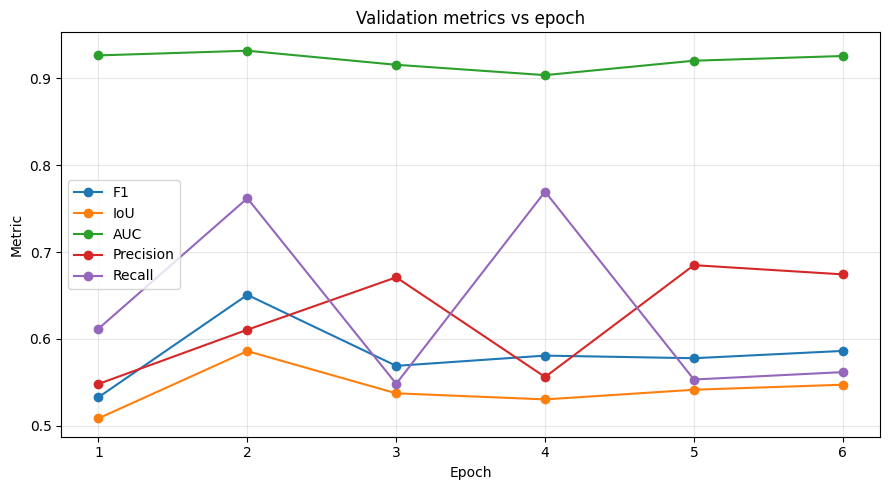

In [47]:
# Plot F1/IoU/AUC/Precision/Recall across epochs
plt.figure(figsize=(9, 5))
for col in ['F1', 'IoU', 'AUC', 'Precision', 'Recall']:
    plt.plot(metrics_df['epoch'], metrics_df[col], marker='o', label=col)
plt.xlabel('Epoch')
plt.ylabel('Metric')
plt.title('Validation metrics vs epoch')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

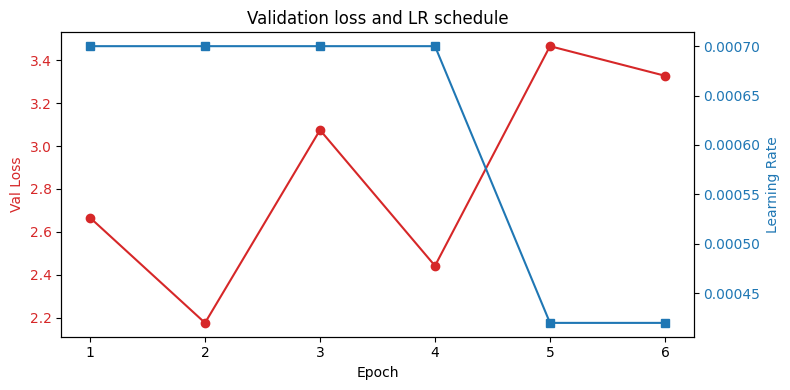

In [48]:
# Plot validation loss and learning rate
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(metrics_df['epoch'], metrics_df['loss'], marker='o', color='tab:red', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Val Loss', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax2 = ax1.twinx()
ax2.plot(metrics_df['epoch'], metrics_df['LR'], marker='s', color='tab:blue', label='LR')
ax2.set_ylabel('Learning Rate', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
plt.title('Validation loss and LR schedule')
fig.tight_layout()
plt.show()

In [49]:
# Best epoch summary
best = metrics_df.sort_values('F1', ascending=False).iloc[0]
best[['epoch','F1','IoU','AUC','Precision','Recall','loss']]

epoch        2.0000
F1           0.6507
IoU          0.5860
AUC          0.9317
Precision    0.6106
Recall       0.7619
loss         2.1751
Name: 1, dtype: float64